In [1]:
# ──────────────────────────────────────────────────────────────
# CELL 1: Imports & Setup
# ──────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Setup complete ✓")

Setup complete ✓


In [2]:
# ──────────────────────────────────────────────────────────────
# CELL 2: Data Download & Preparation (2025 full year)
# ──────────────────────────────────────────────────────────────

tickers = ["AAPL", "GOOGL", "MSFT", "NVDA", "TSLA"]
start_date = "2025-01-01"
end_date   = "2025-12-31"

print("Downloading data...")
data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', progress=False)

# Long format
dfs = []
for ticker in tickers:
    df_t = data[ticker][['Open', 'Close', 'Volume']].copy()
    df_t['Ticker'] = ticker
    dfs.append(df_t)

df = pd.concat(dfs).dropna()
df = df.sort_index()

# Targets = close at t+h (horizon days ahead)
horizons = [1, 2, 3, 4, 5]
for h in horizons:
    df[f'Target_t{h}'] = df.groupby('Ticker')['Close'].shift(-h)

df = df.dropna(subset=[f'Target_t{h}' for h in horizons])

print(f"Data shape: {df.shape}")
print("
Samples per stock:")
print(df['Ticker'].value_counts())


/var/folders/80/rq5jt3mx16z7lyw2xgr6zlgc0000gn/T/ipykernel_74777/3631155023.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', progress=False)


Data shape: (1240, 5)

Samples per stock:
Ticker
AAPL     248
MSFT     248
NVDA     248
GOOGL    248
TSLA     248
Name: count, dtype: int64


In [3]:
# ──────────────────────────────────────────────────────────────
# CELL 3: Feature Engineering
# ──────────────────────────────────────────────────────────────

def add_benchmark_features(group):
    group['Past_3d_Mean'] = group['Close'].rolling(3).mean().shift(1)
    group['Past_5d_Vol']  = group['Close'].pct_change().rolling(5).std().shift(1) * np.sqrt(252)
    return group

def add_advanced_features(group):
    # Lags
    for lag in [1,2,3,5,7,10,20]:
        group[f'Lag_{lag}'] = group['Close'].shift(lag)

    # Moving averages
    for w in [5,10,20,50]:
        group[f'SMA_{w}']  = group['Close'].rolling(w).mean()
        group[f'EWMA_{w}'] = group['Close'].ewm(span=w, adjust=False).mean()

    # Volatility
    for w in [10,20,30]:
        group[f'Vol_{w}d'] = group['Close'].pct_change().rolling(w).std() * np.sqrt(252)

    # RSI
    delta = group['Close'].diff()
    gain = delta.where(delta>0,0).rolling(14).mean()
    loss = -delta.where(delta<0,0).rolling(14).mean()
    rs = gain / (loss + 1e-9)
    group['RSI_14'] = 100 - (100 / (1 + rs))

    # Simple momentum / ROC
    group['ROC_5']  = group['Close'].pct_change(5) * 100
    group['ROC_10'] = group['Close'].pct_change(10) * 100

    return group

# Apply features (important: groupby to prevent leakage)
df = df.groupby('Ticker', group_keys=False).apply(add_benchmark_features)
df = df.groupby('Ticker', group_keys=False).apply(add_advanced_features)
df = df.dropna()

print(f"After feature engineering: {df.shape}")

After feature engineering: (995, 28)


/var/folders/80/rq5jt3mx16z7lyw2xgr6zlgc0000gn/T/ipykernel_74777/2899567204.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Ticker', group_keys=False).apply(add_benchmark_features)
/var/folders/80/rq5jt3mx16z7lyw2xgr6zlgc0000gn/T/ipykernel_74777/2899567204.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Ticker', group_keys=False).apply(add_advanced_features)


In [13]:
# ──────────────────────────────────────────────────────────────
# CELL 4: Prepare Datasets + Define Evaluation Function
# ──────────────────────────────────────────────────────────────

df_model = df.drop(columns=['Ticker'])

target_cols = [c for c in df_model.columns if c.startswith('Target_t')]
benchmark_cols = ['Open', 'Past_3d_Mean', 'Past_5d_Vol']
all_feature_cols = [c for c in df_model.columns if c not in target_cols]

def evaluate_model(X, y, close_series, name="Model", n_estimators=120):
    tscv = TimeSeriesSplit(n_splits=5)
    results = {'rmse':[], 'mae':[], 'mape':[], 'r2':[], 'theil_u':[], 'dir_acc':[]}

    y_naive = []  # for Theil's U
    y_true_all = []
    y_pred_all = []

    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Access current 'Close' for test set (for directional accuracy)
        close_test = close_series.iloc[test_idx].values

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        model = RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1)
        model.fit(X_train_s, y_train)

        y_pred = model.predict(X_test_s)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
        r2   = r2_score(y_test, y_pred)

        # Naive forecast = last observed value
        naive_pred = y_test.shift(1).fillna(y_test.iloc[0])
        theil_u = np.sqrt(np.mean((y_test - y_pred)**2) / np.mean((y_test - naive_pred)**2))

        # Directional accuracy vs today's close
        actual_dir = (y_test > close_test).astype(int)
        pred_dir = (y_pred > close_test).astype(int)
        dir_acc = np.mean(actual_dir == pred_dir)

        results['rmse'].append(rmse)
        results['mae'].append(mae)
        results['mape'].append(mape)
        results['r2'].append(r2)
        results['theil_u'].append(theil_u)
        results['dir_acc'].append(dir_acc)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_naive.extend(naive_pred)

    df_results = pd.DataFrame(results)

    print(f"
{name} Performance (5-fold TimeSeries CV):")
    print(df_results.round(4))
    print("
Average:")
    print(df_results.mean(numeric_only=True).round(4))

    return df_results, np.array(y_true_all), np.array(y_pred_all), model


In [14]:
# ──────────────────────────────────────────────────────────────
# CELL 5: Run Benchmark & Advanced Models + Compare
# ──────────────────────────────────────────────────────────────

close_series = df_model['Close']
summary_rows = []

for h in horizons:
    y = df_model[f'Target_t{h}']

    print("═"*70)
    print(f"Horizon t+{h}")
    print("Training Benchmark...")
    bench_results, bench_true, bench_pred, bench_model = evaluate_model(
        df_model[benchmark_cols], y, close_series, f"BENCHMARK (t+{h})", n_estimators=100
    )

    print("─"*70)
    print("Training Advanced...")
    adv_results, adv_true, adv_pred, adv_model = evaluate_model(
        df_model[all_feature_cols], y, close_series, f"ADVANCED FEATURES (t+{h})", n_estimators=140
    )

    summary_rows.append({
        'horizon': f't+{h}',
        'model': 'benchmark',
        'dir_acc_mean': bench_results['dir_acc'].mean(),
        'dir_acc_std': bench_results['dir_acc'].std(),
    })
    summary_rows.append({
        'horizon': f't+{h}',
        'model': 'advanced',
        'dir_acc_mean': adv_results['dir_acc'].mean(),
        'dir_acc_std': adv_results['dir_acc'].std(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_pivot = summary_df.pivot(index='horizon', columns='model', values='dir_acc_mean').round(4)
summary_pivot = summary_pivot.rename(columns={'benchmark': 'basic_features', 'advanced': 'advanced_features'})

print("═"*70)
print("Directional Accuracy Summary")
print(summary_pivot)

try:
    display(summary_pivot)
except NameError:
    pass


Training Benchmark...

BENCHMARK Performance (5-fold TimeSeries CV):
      rmse      mae    mape      r2  theil_u  dir_acc
0  23.3012  15.8058  5.4294  0.9625   0.1055   0.4606
1  15.0600  10.3516  3.3109  0.9857   0.0671   0.5030
2  13.8382  10.1407  3.6963  0.9872   0.0625   0.5273
3   9.4780   7.2308  2.4500  0.9942   0.0407   0.5152
4  11.6635   8.4015  2.4932  0.9893   0.0552   0.5091

Average:
rmse       14.6682
mae        10.3861
mape        3.4760
r2          0.9838
theil_u     0.0662
dir_acc     0.5030
dtype: float64

══════════════════════════════════════════════════════════════════════
Training Advanced...

ADVANCED FEATURES Performance (5-fold TimeSeries CV):
      rmse      mae    mape      r2  theil_u  dir_acc
0  24.1270  15.2155  4.7961  0.9598   0.1093   0.4848
1  15.2559  10.0461  3.0196  0.9854   0.0679   0.4848
2   9.6549   7.1821  2.4017  0.9938   0.0436   0.5152
3   8.0021   5.9908  1.8649  0.9959   0.0344   0.5091
4  12.0549   9.1057  2.6557  0.9885   0.0571   0.5

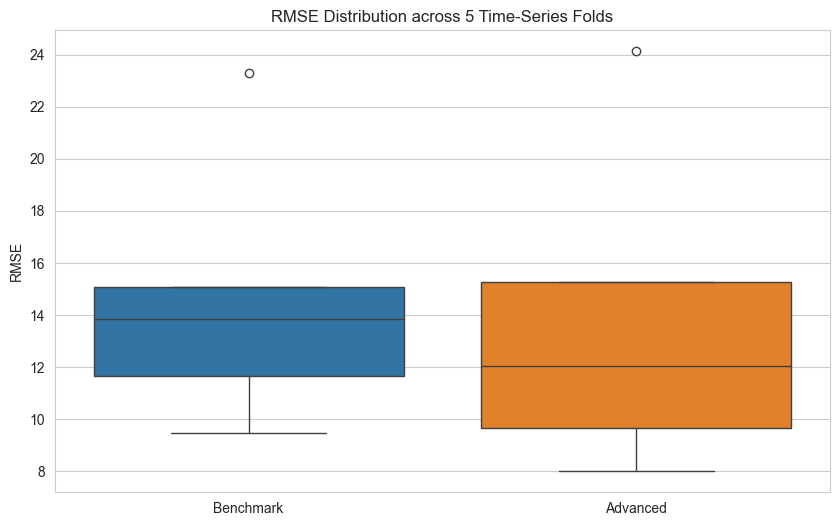

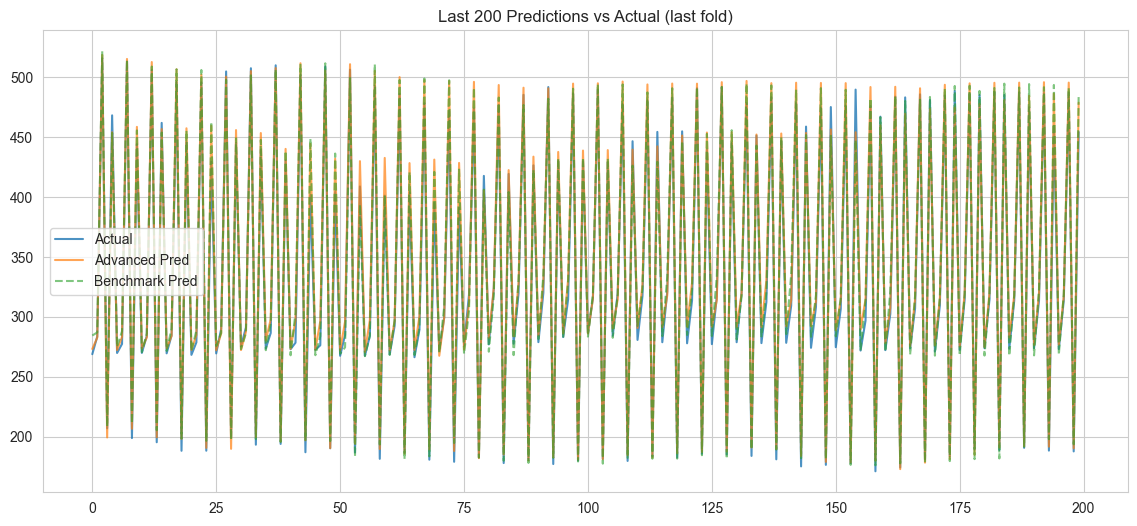

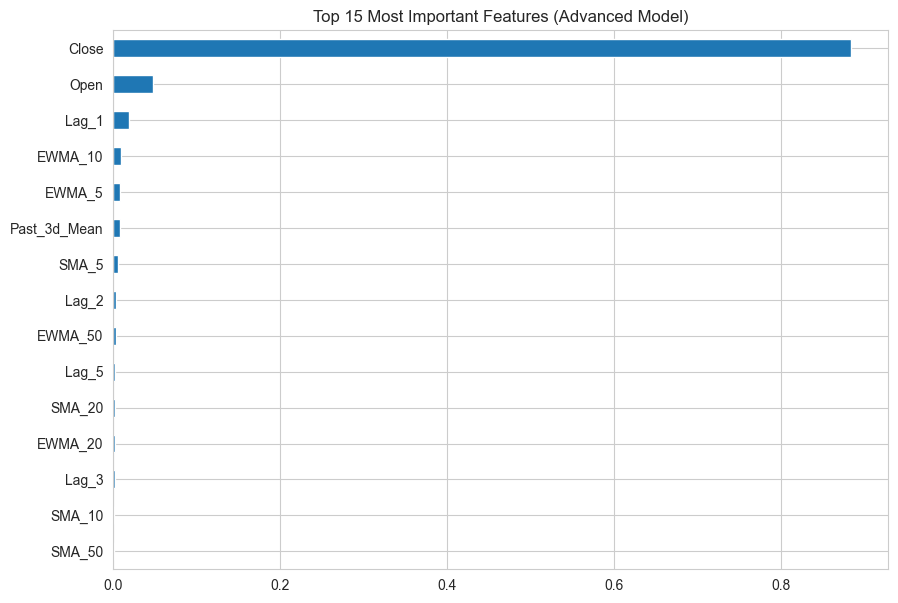

In [6]:
# ──────────────────────────────────────────────────────────────
# CELL 6: Visual Comparison
# ──────────────────────────────────────────────────────────────

# 1. Boxplot comparison
plt.figure(figsize=(10,6))
data_box = pd.DataFrame({
    'Benchmark': bench_results['rmse'],
    'Advanced': adv_results['rmse']
})
sns.boxplot(data=data_box)
plt.title('RMSE Distribution across 5 Time-Series Folds')
plt.ylabel('RMSE')
plt.show()

# 2. Prediction vs Actual (last fold)
plt.figure(figsize=(14,6))
plt.plot(adv_true[-200:], label='Actual', alpha=0.8)
plt.plot(adv_pred[-200:], label='Advanced Pred', alpha=0.7)
plt.plot(bench_pred[-200:], label='Benchmark Pred', alpha=0.6, linestyle='--')
plt.title('Last 200 Predictions vs Actual (last fold)')
plt.legend()
plt.show()

# 3. Feature Importance (Advanced model)
importances = pd.Series(adv_model.feature_importances_, index=all_feature_cols)
importances.nlargest(15).plot(kind='barh', figsize=(10,7))
plt.title('Top 15 Most Important Features (Advanced Model)')
plt.gca().invert_yaxis()
plt.show()